In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .master("local[*]") \
    .getOrCreate()

spark

In [3]:
df = spark.read.csv("creditcard.csv", header=True, inferSchema=True)

df.printSchema()
df.show(5)

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [4]:
df.groupBy("Class").count().show()

+-----+------+
|Class| count|
+-----+------+
|    1|   338|
|    0|154283|
+-----+------+



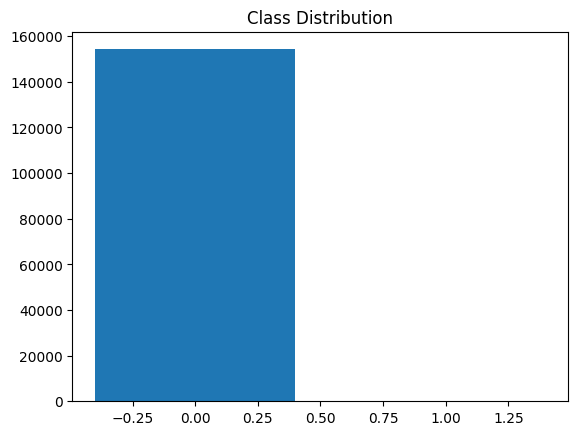

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df.groupBy("Class").count().toPandas()

plt.bar(pdf["Class"], pdf["count"])
plt.title("Class Distribution")
plt.show()

Create Feature Vector

In [6]:
from pyspark.ml.feature import VectorAssembler

features = df.columns[:-1]  # all columns except "Class"

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

df_vec = assembler.transform(df)
df_vec.select("features", "Class").show(5)

+--------------------+-----+
|            features|Class|
+--------------------+-----+
|[0.0,-1.359807133...|    0|
|[0.0,1.1918571113...|    0|
|[1.0,-1.358354061...|    0|
|[1.0,-0.966271711...|    0|
|[2.0,-1.158233093...|    0|
+--------------------+-----+
only showing top 5 rows


Normalize Features

In [7]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures"
)

scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec)

df_scaled.select("scaledFeatures").show(5)

+--------------------+
|      scaledFeatures|
+--------------------+
|[0.0,-0.737543307...|
|[0.0,0.6464492012...|
|[4.37593068759045...|
|[4.37593068759045...|
|[8.75186137518091...|
+--------------------+
only showing top 5 rows


 3. Keep Only Useful Columns

In [8]:
df_final = df_scaled.select("scaledFeatures", "Class")
df_final.show(5)

+--------------------+-----+
|      scaledFeatures|Class|
+--------------------+-----+
|[0.0,-0.737543307...|    0|
|[0.0,0.6464492012...|    0|
|[4.37593068759045...|    0|
|[4.37593068759045...|    0|
|[8.75186137518091...|    0|
+--------------------+-----+
only showing top 5 rows


In [9]:
df_final.printSchema()

root
 |-- scaledFeatures: vector (nullable = true)
 |-- Class: integer (nullable = true)



In [11]:
!pip install pyspark-iforest

ERROR: Could not find a version that satisfies the requirement pyspark-iforest (from versions: none)
ERROR: No matching distribution found for pyspark-iforest


In [12]:
!pip install scikit-learn

In [13]:
pdf = df_final.toPandas()

In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.002,  # same logic as before
    random_state=42
)

pdf["prediction"] = iso.fit_predict(list(pdf["scaledFeatures"]))

In [15]:
pdf["prediction"] = pdf["prediction"].apply(lambda x: 1 if x == -1 else 0)

In [16]:
df_iforest = spark.createDataFrame(pdf)

In [17]:
df_iforest.groupBy("Class", "prediction").count().show()

+-----+----------+------+
|Class|prediction| count|
+-----+----------+------+
|    1|         0|   210|
|    1|         1|   128|
|    0|         1|   182|
|    0|         0|154101|
+-----+----------+------+



 1. Train K-Means

In [18]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=2,  # 2 clusters (fraud vs normal assumption)
    featuresCol="scaledFeatures",
    seed=42
)

model_kmeans = kmeans.fit(df_final)

 2. Make Predictions

In [19]:
df_kmeans = model_kmeans.transform(df_final)

df_kmeans.select("scaledFeatures", "prediction").show(5)

+--------------------+----------+
|      scaledFeatures|prediction|
+--------------------+----------+
|[0.0,-0.737543307...|         1|
|[0.0,0.6464492012...|         1|
|[4.37593068759045...|         1|
|[4.37593068759045...|         0|
|[8.75186137518091...|         1|
+--------------------+----------+
only showing top 5 rows


 3. Compare Clusters with Real Labels

In [20]:
df_kmeans.groupBy("prediction", "Class").count().show()

+----------+-----+------+
|prediction|Class| count|
+----------+-----+------+
|         1|    0|111804|
|         1|    1|    90|
|         0|    0| 42479|
|         0|    1|   248|
+----------+-----+------+



5.  Fraud Rate per Cluster

In [21]:
from pyspark.sql.functions import col

cluster_stats = df_kmeans.groupBy("prediction").count()
fraud_stats = df_kmeans.filter(col("Class") == 1).groupBy("prediction").count()

cluster_stats.show()
fraud_stats.show()

+----------+------+
|prediction| count|
+----------+------+
|         1|111894|
|         0| 42727|
+----------+------+

+----------+-----+
|prediction|count|
+----------+-----+
|         1|   90|
|         0|  248|
+----------+-----+



 Compute weights

In [22]:
from pyspark.sql.functions import when

fraud_count = df.filter(df.Class == 1).count()
normal_count = df.filter(df.Class == 0).count()

balance_ratio = normal_count / fraud_count

print("Balance ratio:", balance_ratio)

Balance ratio: 456.4585798816568


 Add weight column

In [23]:
df_weighted = df_final.withColumn(
    "weight",
    when(df_final.Class == 1, balance_ratio).otherwise(1.0)
)

 STEP 6.2 — Train/Test Split

In [24]:
train_df, test_df = df_weighted.randomSplit([0.8, 0.2], seed=42)

STEP 6.3 — Train Logistic Regression

In [25]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="scaledFeatures",
    labelCol="Class",
    weightCol="weight"
)

lr_model = lr.fit(train_df)

 STEP 6.4 — Predictions

In [26]:
predictions = lr_model.transform(test_df)

predictions.select("Class", "prediction", "probability").show(5)

+-----+----------+--------------------+
|Class|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.97529202611242...|
|    0|       0.0|[0.93824368375565...|
|    0|       0.0|[0.95562480570845...|
|    0|       0.0|[0.92317856718118...|
|    0|       0.0|[0.99340583837164...|
+-----+----------+--------------------+
only showing top 5 rows


STEP 7 — Evaluation 

 AUC-ROC 

In [27]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print("AUC-ROC:", auc)

AUC-ROC: 0.9575902569432381


 Precision / Recall / F1

In [28]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

precision = MulticlassClassificationEvaluator(
    labelCol="Class", metricName="precisionByLabel"
)

recall = MulticlassClassificationEvaluator(
    labelCol="Class", metricName="recallByLabel"
)

f1 = MulticlassClassificationEvaluator(
    labelCol="Class", metricName="f1"
)

print("Precision:", precision.evaluate(predictions))
print("Recall:", recall.evaluate(predictions))
print("F1:", f1.evaluate(predictions))

Precision: 0.9996717652465043
Recall: 0.9837527051907361
F1: 0.989879197448089


 STEP 8 — Confusion Matrix 

In [29]:
predictions.groupBy("Class", "prediction").count().show()

+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    1|       0.0|   10|
|    0|       0.0|30456|
|    1|       1.0|   58|
|    0|       1.0|  503|
+-----+----------+-----+



 STEP 9 — Threshold Tuning 

In [30]:
lr_model.setThreshold(0.3)
pred_tuned = lr_model.transform(test_df)